# Prepare data for finetuning

In [2]:
import os

# Virus DNA

In [ ]:
DATA_DIR="../data/finetuning/phage_data/"
os.makedirs(DATA_DIR, exist_ok=True)

## Download datasets

### NCBI RefSeq bacteriophage genomes

First, install the NCBI Datasets CLI conda package as:

```
mm install -c conda-forge ncbi-datasets-cli
```

(replace `mm` with conda if you are using `conda` instead of micromamba)

In [3]:
folder_name="refseq/"

folder_path = os.path.join(DATA_DIR, folder_name)
os.makedirs(folder_path, exist_ok=True)

!datasets download virus genome taxon "Bacteriophage" --filename phages.zip --no-progressbar
!unzip phages.zip -d phages/
!mv phages/ncbi_dataset/data/* "{folder_path}"
!rm phages.zip
!rm -rf phages/

Archive:  phages.zip
  inflating: phages/README.md        
  inflating: phages/ncbi_dataset/data/data_report.jsonl  
  inflating: phages/ncbi_dataset/data/genomic.fna  
  inflating: phages/ncbi_dataset/data/virus_dataset.md  
  inflating: phages/ncbi_dataset/data/dataset_catalog.json  
  inflating: phages/md5sum.txt       


### PhagesDB

The downloaded link might change. If it does not work, go to `https://phagesdb.org/data/` and click on `Download Multifasta of All Actinobacteriophage Genomes`.

In [10]:
folder_name="phagesdb/"

folder_path = os.path.join(DATA_DIR, folder_name)
os.makedirs(folder_path, exist_ok=True)

!wget -O "{os.path.join(folder_path, 'all_genomes.fasta')}" https://phagesdb.org/media/Actinobacteriophages-All.fasta

--2026-01-06 11:35:50--  https://phagesdb.org/media/Actinobacteriophages-All.fasta
Resolving phagesdb.org (phagesdb.org)... 45.79.158.136
Connecting to phagesdb.org (phagesdb.org)|45.79.158.136|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 352356576 (336M) [application/octet-stream]
Saving to: ‘phage_data/phagesdb/all_genomes.fasta’

phage_data/phagesdb 100%[===================>] 336.03M  30.8MB/s    in 11s     

2026-01-06 11:36:02 (29.4 MB/s) - ‘phage_data/phagesdb/all_genomes.fasta’ saved [352356576/352356576]



### NCBI GenBank Bacteriophages (DNA + RNA)

1. Go to [https://www.ncbi.nlm.nih.gov/nuccore](https://www.ncbi.nlm.nih.gov/nuccore) and search for `bacteriophage[Organism]`
2. Click on `Send to:` -> **File**, Format: **FASTA** -> `Create File`
3. Save it under *DATA_DIR/genbank*

In [11]:
folder_name = "genbank"

os.makedirs(os.path.join(DATA_DIR, folder_name), exist_ok=True)

## Data preprocessing

In [69]:
import os
from pathlib import Path
from Bio import SeqIO
from datasets import Dataset
from tqdm import tqdm
import pandas as pd
from matplotlib import pyplot as plt

In [70]:
# MAX_LEN = 2048
# MAX_LEN = 12288
MAX_LEN = 32768 - 1
MIN_LEN = 1000
VALID_CHARS = {"A", "C", "G", "T", "N"}

In [71]:
# Set to uppercase, remove whitespaces and replace any unknown character with N
def clean_sequence(seq: str) -> str:
    seq = seq.upper().replace(" ", "").replace("\n", "")
    cleaned = "".join(c if c in VALID_CHARS else "N" for c in seq)
    return cleaned

def load_all_sequences(fasta_dir: str, min_len: int) -> list[str]:
    """
    Loads all FASTA files inside `fasta_dir`.
    Returns a list of cleaned sequences.
    """
    sequences = []

    # fasta_files = list(Path(fasta_dir).glob("**/*.fasta")) + \
    #               list(Path(fasta_dir).glob("**/*.fa")) + \
    #               list(Path(fasta_dir).glob("**/*.fna")) + \
    #               list(Path(fasta_dir).glob("**/*.fas"))


    fasta_files = list(Path(fasta_dir).glob("**/*.fna"))
    # fasta_files = list(Path(fasta_dir).glob("**/*.fas"))

    print(f"Found {len(fasta_files)} FASTA files.")

    for fasta_path in fasta_files:
        for record in tqdm(SeqIO.parse(str(fasta_path), "fasta"), desc=f"Loading {fasta_path}"):
            raw_seq = str(record.seq)
            cleaned = clean_sequence(raw_seq)

            if len(cleaned) >= min_len:
                sequences.append(cleaned)

    print(f"Loaded {len(sequences)} sequences.")
    return sequences

In [72]:
# Remove duplicates with hashing
def deduplicate_sequences(sequences: list[str]) -> list[str]:
    unique = {}
    for seq in tqdm(sequences, desc="Deduplicating..."):
        h = hash(seq)
        unique[h] = seq
    deduped = list(unique.values())
    print(f"Removed {len(sequences) - len(deduped)} sequences. {len(deduped)} remaining.")
    return deduped

In [73]:
def chunk_sequence(seq: str, max_len: int = MAX_LEN) -> list[str]:
    return [seq[i:i+max_len] for i in range(0, len(seq), max_len)]

# Divide long sequences
def chunk_sequences(sequences: list[str], max_len: int) -> list[str]:
    chunks = []

    for seq in sequences:
        if len(seq) <= max_len:
            chunks.append(seq)
        else:
            chunks.extend(chunk_sequence(seq, max_len))

    print(f"Total chunks: {len(chunks)}")
    return chunks

## Process dataset

In [74]:
sequences = load_all_sequences(DATA_DIR, MIN_LEN)

Found 1302 FASTA files.


Loading phage_data/ncbi_dataset/data/GCA_012626855.1/GCA_012626855.1_ASM1262685v1_genomic.fna: 1it [00:00, 368.31it/s]


Loading phage_data/ncbi_dataset/data/GCA_029972285.1/GCA_029972285.1_ASM2997228v1_genomic.fna: 1it [00:00, 650.28it/s]
Loading phage_data/ncbi_dataset/data/GCA_029971645.1/GCA_029971645.1_ASM2997164v1_genomic.fna: 1it [00:00, 897.37it/s]
Loading phage_data/ncbi_dataset/data/GCA_029968985.1/GCA_029968985.1_ASM2996898v1_genomic.fna: 1it [00:00, 409.48it/s]
Loading phage_data/ncbi_dataset/data/GCA_900327445.1/GCA_900327445.1_2H04.1_genomic.fna: 1it [00:00, 688.61it/s]
Loading phage_data/ncbi_dataset/data/GCA_012626945.1/GCA_012626945.1_ASM1262694v1_genomic.fna: 1it [00:00, 532.41it/s]
Loading phage_data/ncbi_dataset/data/GCA_012615565.1/GCA_012615565.1_ASM1261556v1_genomic.fna: 1it [00:00, 804.43it/s]
Loading phage_data/ncbi_dataset/data/GCA_029970725.1/GCA_029970725.1_ASM2997072v1_genomic.fna: 1it [00:00, 130.19it/s]
Loading phage_data/ncbi_dataset/data/GCA_029971535.1/GCA_029971535.1_ASM2997153v1_genomic.fna: 1it [00:00, 738.95it/s]
Loading phage_data/ncbi_dataset/data/GCA_012616165.1/

Loaded 1302 sequences.


In [75]:
sequences = deduplicate_sequences(sequences)

Deduplicating...: 100%|██████████| 1302/1302 [00:00<00:00, 39139.54it/s]

Removed 0 sequences. 1302 remaining.


In [76]:
chunks = chunk_sequences(sequences, MAX_LEN)

Total chunks: 2476


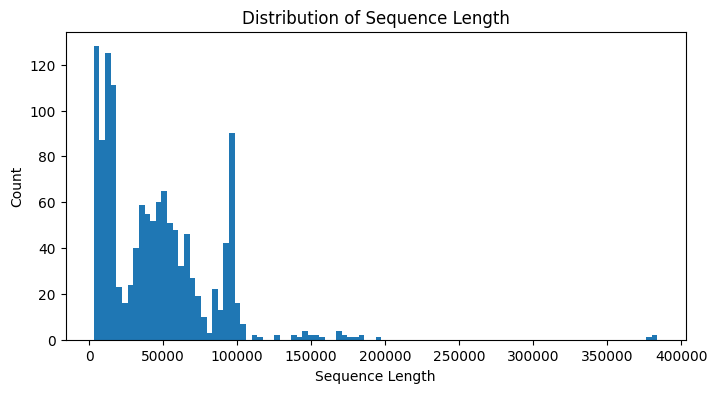

In [82]:
plt.figure(figsize=(8, 4))
plt.hist(list(map(len, sequences)), bins=100)
plt.xlabel('Sequence Length')
plt.ylabel('Count')
plt.title('Distribution of Sequence Length')
plt.show()

In [78]:
print(f"Mean sequence length: {sum(map(len, sequences)) / len(sequences):.2f}")

Mean sequence length: 44916.01


In [79]:
sum_perc_null = 0
for s in tqdm(sequences):
    # sum_perc_null += len(list(filter(lambda x: x not in "ACGT", s))) / len(s)
    valid = s.count("A") + s.count("C") + s.count("G") + s.count("T")
    sum_perc_null += (len(s) - valid) / len(s)
print(f"Average percentage of non-ACGT characters: {sum_perc_null/len(sequences) * 100}")

100%|██████████| 1302/1302 [00:00<00:00, 1757.65it/s]

Average percentage of non-ACGT characters: 0.0


In [9]:
hf_dataset = Dataset.from_dict({"sequence": chunks})
print(hf_dataset)

Dataset({
    features: ['sequence'],
    num_rows: 208752
})


In [10]:
hf_dataset.save_to_disk(os.path.join(DATA_DIR, "phage_clean_dataset"))

Saving the dataset (0/1 shards):   0%|          | 0/208752 [00:00<?, ? examples/s]

## Local dataset

In [8]:
def load_perphect_sequences(data_dir: str):
    bact = pd.read_csv(os.path.join(data_dir, "bacteria_df.csv"))["bacterium_sequence"].tolist()
    phag = pd.read_csv(os.path.join(data_dir, "phages_df.csv"))["phage_sequence"].tolist()

    return bact, phag

bact_sequences, phag_sequences = load_perphect_sequences("../data/perphect-data/all/")

In [9]:
bact_chunks = chunk_sequences(deduplicate_sequences(bact_sequences), MAX_LEN)
phag_chunks = chunk_sequences(deduplicate_sequences(phag_sequences), MAX_LEN)

Deduplicating...: 100%|██████████| 231/231 [00:00<00:00, 298.41it/s]


Removed 5 sequences. 226 remaining.
Total chunks: 33394


Deduplicating...: 100%|██████████| 3539/3539 [00:00<00:00, 29827.35it/s]

Removed 339 sequences. 3200 remaining.


Total chunks: 8216


In [10]:
phages_hf_dataset = Dataset.from_dict({"sequence": phag_chunks})
print(phages_hf_dataset)

Dataset({
    features: ['sequence'],
    num_rows: 8216
})


In [11]:
bact_hf_dataset = Dataset.from_dict({"sequence": bact_chunks})
print(bact_hf_dataset)

Dataset({
    features: ['sequence'],
    num_rows: 33394
})


In [12]:
phages_hf_dataset.save_to_disk(os.path.join(DATA_DIR, f"perphect_phage_dataset_{MAX_LEN}"))
bact_hf_dataset.save_to_disk(os.path.join(DATA_DIR, f"perphect_bacteria_dataset_{MAX_LEN}"))

Saving the dataset (0/1 shards):   0%|          | 0/8216 [00:00<?, ? examples/s]

Saving the dataset (0/3 shards):   0%|          | 0/33394 [00:00<?, ? examples/s]